In [11]:
from google.colab import drive
drive.mount('/mnt_drive')


Mounted at /mnt_drive


In [16]:
from pathlib import Path

# Try both possible mount points
for candidate in ["/content/drive/MyDrive", "/mnt_drive/MyDrive"]:
    if Path(candidate).exists():
        DRIVE_ROOT = Path(candidate)
        break
else:
    raise RuntimeError("Drive not mounted. Please run drive.mount(...) first.")

BASE_DIR = DRIVE_ROOT / "project_visual_search"
RAW_DIR = BASE_DIR / "data" / "raw"
ANN_DIR = BASE_DIR / "data" / "annotations"


In [21]:
from pathlib import Path

# Lock to the correct mount (confirmed: /mnt_drive)
BASE_DIR = Path("/mnt_drive/MyDrive/project_visual_search")

RAW_DIR = BASE_DIR / "data" / "raw"
ANN_DIR = BASE_DIR / "data" / "annotations"

MANIFEST_PATH = BASE_DIR / "data" / "raw_image_first_manifest.csv"
THUMBS_DIR = BASE_DIR / "data" / "thumbs"
THUMBS_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("RAW_DIR exists?", RAW_DIR.exists(), "-", RAW_DIR)
print("ANN_DIR exists?", ANN_DIR.exists(), "-", ANN_DIR)
print("Manifest will be saved to:", MANIFEST_PATH)
print("Thumbs will be saved in:", THUMBS_DIR)


BASE_DIR: /mnt_drive/MyDrive/project_visual_search
RAW_DIR exists? True - /mnt_drive/MyDrive/project_visual_search/data/raw
ANN_DIR exists? True - /mnt_drive/MyDrive/project_visual_search/data/annotations
Manifest will be saved to: /mnt_drive/MyDrive/project_visual_search/data/raw_image_first_manifest.csv
Thumbs will be saved in: /mnt_drive/MyDrive/project_visual_search/data/thumbs


In [22]:
# Collect all tif/jpg images from RAW_DIR recursively
image_files = []
for ext in ["*.tif", "*.TIF", "*.tiff", "*.jpg", "*.JPG", "*.jpeg", "*.JPEG"]:
    image_files.extend(RAW_DIR.rglob(ext))

print(f"Total image files found: {len(image_files)}")

# Sort for consistency
image_files = sorted(image_files)

# Show sample from development-set
print("\nSample from development-set:")
for f in image_files:
    if "development-set" in str(f):
        print(" ", f.relative_to(RAW_DIR))
    if "development-set" in str(f) and f.suffix.lower() == ".tif":
        break  # stop after first tif+jpg pair

# Show sample from sample-set
print("\nSample from sample-set:")
for f in image_files:
    if "sample-set" in str(f):
        print(" ", f.relative_to(RAW_DIR))
    if "sample-set" in str(f) and f.suffix.lower() == ".tif":
        break


Total image files found: 322

Sample from development-set:
  development-set/GC01PS03D0001.jpg
  development-set/GC01PS03D0001.tif

Sample from sample-set:
  sample-set/brick_kiln/GC01PS03D0011.jpg
  sample-set/brick_kiln/GC01PS03D0011.tif


In [24]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 104.3 MB/s eta 0:00:00


Development sample (tif): True /mnt_drive/MyDrive/project_visual_search/data/raw/development-set/GC01PS03D0001.tif
Development sample (jpg): True /mnt_drive/MyDrive/project_visual_search/data/raw/development-set/GC01PS03D0001.jpg
Sample-set example (tif): True /mnt_drive/MyDrive/project_visual_search/data/raw/sample-set/brick_kiln/GC01PS03D0011.tif
Sample-set example (jpg): True /mnt_drive/MyDrive/project_visual_search/data/raw/sample-set/brick_kiln/GC01PS03D0011.jpg

---

Inspecting development TIF...


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


  width: 2037
  height: 1401
  bands: 4
  crs: None
  dtype: uint16
  nodata: 0.0
  sample_min: [0.0, 0.0, 0.0, 0.0]
  sample_max: [3129.0, 2537.0, 1691.0, 5446.0]
  sample_mean: [668.9884033203125, 831.8329467773438, 562.7788696289062, 3516.2216796875]

Inspecting sample-set TIF...
  width: 2041
  height: 1389
  bands: 4
  crs: None
  dtype: uint16
  nodata: 0.0
  sample_min: [0.0, 0.0, 0.0, 0.0]
  sample_max: [3336.0, 2825.0, 2003.0, 4605.0]
  sample_mean: [1740.1571044921875, 1447.0045166015625, 1006.1282958984375, 3080.611083984375]

Showing development JPG (visual check):


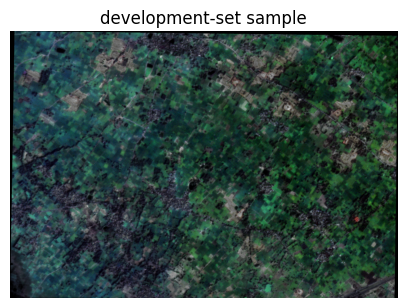


Showing sample-set JPG (visual check):


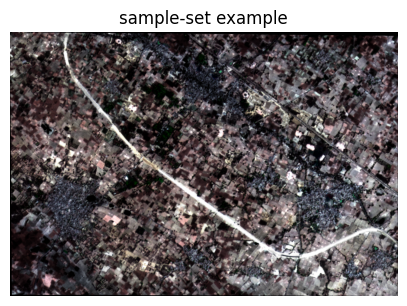

In [25]:
# Cell 3 — inspect metadata & quick stats for two example images
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Examples detected earlier (change these if you want different files)
dev_tif = RAW_DIR / "development-set" / "GC01PS03D0001.tif"
dev_jpg = RAW_DIR / "development-set" / "GC01PS03D0001.jpg"

sample_tif = RAW_DIR / "sample-set" / "brick_kiln" / "GC01PS03D0011.tif"
sample_jpg = RAW_DIR / "sample-set" / "brick_kiln" / "GC01PS03D0011.jpg"

print("Development sample (tif):", dev_tif.exists(), dev_tif)
print("Development sample (jpg):", dev_jpg.exists(), dev_jpg)
print("Sample-set example (tif):", sample_tif.exists(), sample_tif)
print("Sample-set example (jpg):", sample_jpg.exists(), sample_jpg)
print("\n---\n")

# Use rasterio for TIF metadata & stats (safe downsample)
try:
    import rasterio
    from rasterio.enums import Resampling
    def inspect_tif(p):
        with rasterio.open(p) as ds:
            w,h = ds.width, ds.height
            bands = ds.count
            crs = ds.crs.to_string() if ds.crs else None
            dtype = ds.dtypes[0] if ds.dtypes else None
            nodata = ds.nodata
            # read small sample (max 512 x 512) to compute stats
            out_h = min(512, h)
            out_w = min(512, w)
            arr = ds.read(out_shape=(bands, out_h, out_w), resampling=Resampling.average).astype('float32')
            mins = arr.reshape(bands, -1).min(axis=1)
            maxs = arr.reshape(bands, -1).max(axis=1)
            means = arr.reshape(bands, -1).mean(axis=1)
        return dict(width=w, height=h, bands=bands, crs=crs, dtype=dtype, nodata=nodata,
                    sample_min=mins.tolist(), sample_max=maxs.tolist(), sample_mean=means.tolist())
    print("Inspecting development TIF...")
    d_dev = inspect_tif(dev_tif)
    for k,v in d_dev.items():
        print(f"  {k}: {v}")
    print("\nInspecting sample-set TIF...")
    d_samp = inspect_tif(sample_tif)
    for k,v in d_samp.items():
        print(f"  {k}: {v}")
except Exception as e:
    print("Error inspecting TIFs with rasterio:", e)
    print("If rasterio is not installed, we can fallback to PIL for JPGs only.")

# Display JPGs for quick visual sanity check
def show_image(p, title=None):
    try:
        im = Image.open(p)
        plt.figure(figsize=(5,5))
        plt.imshow(im)
        plt.axis('off')
        if title: plt.title(title)
        plt.show()
    except Exception as e:
        print("Could not open image", p, e)

print("\nShowing development JPG (visual check):")
show_image(dev_jpg, "development-set sample")

print("\nShowing sample-set JPG (visual check):")
show_image(sample_jpg, "sample-set example")


In [26]:
# Cell 4 — create manifest + thumbnails (single safe pass)
import csv
from pathlib import Path
import numpy as np
from tqdm import tqdm
from PIL import Image

# rasterio may already be installed
import rasterio
from rasterio.enums import Resampling

# helpers
def scale_percentile_uint8(arr, pmin=2, pmax=98):
    """Scale a (bands,H,W) float32 array to uint8 using per-band percentiles."""
    if arr.ndim == 3:
        out = np.zeros((arr.shape[1], arr.shape[2], 3), dtype=np.uint8)
        # prefer first 3 bands if available, otherwise repeat channels
        use_bands = min(3, arr.shape[0])
        for i in range(use_bands):
            band = arr[i]
            lo = np.percentile(band, pmin)
            hi = np.percentile(band, pmax)
            if hi - lo <= 1e-6:
                out[..., i] = np.clip(band, 0, 255).astype(np.uint8)
            else:
                res = (band - lo) / (hi - lo)
                out[..., i] = np.clip((res * 255), 0, 255).astype(np.uint8)
        if use_bands == 1:
            out = np.repeat(out[..., :1], 3, axis=2)
        return out
    else:
        # single band -> gray -> RGB
        a = arr
        lo = np.percentile(a, pmin)
        hi = np.percentile(a, pmax)
        if hi - lo <= 1e-6:
            u8 = np.clip(a, 0, 255).astype(np.uint8)
        else:
            u8 = np.clip(((a - lo) / (hi - lo) * 255), 0, 255).astype(np.uint8)
        return np.stack([u8]*3, axis=2)

def inspect_image(path, sample_maxsize=512):
    """Return a metadata dict and a small sampled array (bands, h, w) as float32."""
    meta = {}
    if str(path).lower().endswith((".tif", ".tiff")):
        try:
            with rasterio.open(path) as ds:
                w,h = ds.width, ds.height
                bands = ds.count
                crs = ds.crs.to_string() if ds.crs else None
                dtype = ds.dtypes[0] if ds.dtypes else None
                nodata = ds.nodata
                # read a downsampled version
                out_h = min(sample_maxsize, h)
                out_w = min(sample_maxsize, w)
                arr = ds.read(out_shape=(bands, out_h, out_w), resampling=Resampling.average).astype('float32')
                # compute nodata percentage using mask if available
                try:
                    mask = ds.read_masks(1, out_shape=(out_h, out_w))
                    percent_nodata = 100.0 * (mask == 0).sum() / (out_h * out_w)
                except Exception:
                    percent_nodata = 0.0
                # per-band stats from sample
                mins = arr.reshape(bands, -1).min(axis=1).tolist()
                maxs = arr.reshape(bands, -1).max(axis=1).tolist()
                means = arr.reshape(bands, -1).mean(axis=1).tolist()
            meta.update(dict(width=w, height=h, bands=bands, crs=crs, dtype=dtype,
                             nodata=nodata, percent_nodata=round(percent_nodata,3),
                             sample_min=mins, sample_max=maxs, sample_mean=means,
                             status="ok"))
            return meta, arr
        except Exception as e:
            return {"status": f"error:{e}"}, None
    else:
        # image types handled via PIL
        try:
            im = Image.open(path)
            w,h = im.size
            arr = np.asarray(im)
            if arr.ndim == 2:
                bands = 1
                arr = arr[np.newaxis, ...].astype('float32')
            else:
                bands = arr.shape[2]
                arr = np.transpose(arr, (2,0,1)).astype('float32')  # C,H,W
            mins = arr.reshape(arr.shape[0], -1).min(axis=1).tolist()
            maxs = arr.reshape(arr.shape[0], -1).max(axis=1).tolist()
            means = arr.reshape(arr.shape[0], -1).mean(axis=1).tolist()
            meta = dict(width=w, height=h, bands=bands, crs=None, dtype=str(arr.dtype),
                        nodata=None, percent_nodata=0.0,
                        sample_min=mins, sample_max=maxs, sample_mean=means,
                        status="ok")
            return meta, arr
        except Exception as e:
            return {"status": f"error:{e}"}, None

# prepare file list
img_paths = []
for ext in ["*.tif","*.tiff","*.TIF","*.jpg","*.JPG","*.jpeg"]:
    img_paths.extend(list(RAW_DIR.rglob(ext)))
img_paths = sorted(img_paths)

print("Found", len(img_paths), "images. Starting manifest generation...")

# write CSV header
header = ["filename","set","width","height","bands","crs","dtype","nodata","percent_nodata",
          "sample_min","sample_max","sample_mean","thumb","status"]

with open(MANIFEST_PATH, "w", newline='', encoding='utf-8') as csvf:
    writer = csv.writer(csvf)
    writer.writerow(header)
    for p in tqdm(img_paths, desc="Manifest"):
        rel = p.relative_to(RAW_DIR)
        # determine which set (sample or development) and class if present
        parts = rel.parts
        set_name = parts[0] if len(parts) > 0 else ""
        try:
            meta, sample_arr = inspect_image(p)
            if meta.get("status","").startswith("error"):
                row = [str(rel), set_name, None, None, None, None, None, None, None, None, None, None, "", meta["status"]]
                writer.writerow(row)
                continue

            # create thumbnail (256x256) from sampled arr (scale percentiles)
            if sample_arr is not None:
                try:
                    thumb_img = scale_percentile_uint8(sample_arr)  # H,W,3
                    pil = Image.fromarray(thumb_img)
                    pil = pil.resize((256,256))
                    thumb_name = f"{rel.as_posix().replace('/', '_')}.jpg"
                    thumb_path = THUMBS_DIR / thumb_name
                    pil.save(thumb_path, quality=85)
                    thumb_rel = str(thumb_path.relative_to(BASE_DIR))
                except Exception as e:
                    thumb_rel = ""
            else:
                thumb_rel = ""

            row = [
                str(rel),
                set_name,
                meta.get("width"),
                meta.get("height"),
                meta.get("bands"),
                meta.get("crs"),
                meta.get("dtype"),
                meta.get("nodata"),
                meta.get("percent_nodata"),
                ";".join(map(str, meta.get("sample_min",[]))),
                ";".join(map(str, meta.get("sample_max",[]))),
                ";".join(map(str, meta.get("sample_mean",[]))),
                thumb_rel,
                meta.get("status","ok")
            ]
            writer.writerow(row)
        except Exception as e:
            writer.writerow([str(rel), set_name, None, None, None, None, None, None, None, None, None, None, "", f"error:{e}"])

print("Manifest saved to:", MANIFEST_PATH)
print("Thumbnails saved to:", THUMBS_DIR)


Found 322 images. Starting manifest generation...


Manifest: 100%|██████████| 322/322 [03:49<00:00,  1.41it/s]

Manifest saved to: /mnt_drive/MyDrive/project_visual_search/data/raw_image_first_manifest.csv
Thumbnails saved to: /mnt_drive/MyDrive/project_visual_search/data/thumbs


In [27]:
import pandas as pd
pd.read_csv(MANIFEST_PATH).head(10)

,filename,set,width,height,bands,crs,dtype,nodata,percent_nodata,sample_min,sample_max,sample_mean,thumb,status
0,development-set/GC01PS03D0001.jpg,development-set,2037,1401,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,184.03982543945312;152.7432861328125;157.31864...,data/thumbs/development-set_GC01PS03D0001.jpg.jpg,ok
1,development-set/GC01PS03D0001.tif,development-set,2037,1401,4,NaN,uint16,0.0,1.957,0.0;0.0;0.0;0.0,3129.0;2537.0;1691.0;5446.0,668.9884033203125;831.8329467773438;562.778869...,data/thumbs/development-set_GC01PS03D0001.tif.jpg,ok
2,development-set/GC01PS03D0002.jpg,development-set,2037,1401,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,92.12244415283203;99.32591247558594;92.2324218...,data/thumbs/development-set_GC01PS03D0002.jpg.jpg,ok
3,development-set/GC01PS03D0002.tif,development-set,2037,1401,4,NaN,uint16,0.0,1.957,0.0;0.0;0.0;0.0,3301.0;2502.0;1805.0;4868.0,2309.35302734375;1891.7686767578125;1248.69140...,data/thumbs/development-set_GC01PS03D0002.tif.jpg,ok
4,development-set/GC01PS03D0007.jpg,development-set,1960,1583,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,191.25804138183594;167.2568817138672;184.62640...,data/thumbs/development-set_GC01PS03D0007.jpg.jpg,ok
5,development-set/GC01PS03D0007.tif,development-set,1960,1583,4,NaN,uint16,0.0,1.603,0.0;0.0;0.0;0.0,3215.0;2887.0;2217.0;5769.0,642.93994140625;842.8341064453125;555.19708251...,data/thumbs/development-set_GC01PS03D0007.tif.jpg,ok
6,development-set/GC01PS03D0008.jpg,development-set,1960,1583,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,129.57443237304688;127.74179077148438;131.2966...,data/thumbs/development-set_GC01PS03D0008.jpg.jpg,ok
7,development-set/GC01PS03D0008.tif,development-set,1960,1583,4,NaN,uint16,0.0,1.603,0.0;0.0;0.0;0.0,2551.0;2199.0;1789.0;4537.0,1097.7841796875;1107.103271484375;781.50482177...,data/thumbs/development-set_GC01PS03D0008.tif.jpg,ok
8,development-set/GC01PS03D0009.jpg,development-set,1960,1583,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,170.32427978515625;150.61700439453125;166.5542...,data/thumbs/development-set_GC01PS03D0009.jpg.jpg,ok
9,development-set/GC01PS03D0009.tif,development-set,1960,1583,4,NaN,uint16,0.0,1.603,0.0;0.0;0.0;0.0,3017.0;2614.0;2144.0;5776.0,856.1702270507812;924.2203979492188;656.923095...,data/thumbs/development-set_GC01PS03D0009.tif.jpg,ok


In [28]:
# cell 5
# Enhance manifest: add filesize_mb, has_pair, sample_std, percent_zero, cloud_score; save CSV+parquet
import pandas as pd
import numpy as np
from pathlib import Path
import os
from tqdm import tqdm
from PIL import Image

# rasterio for TIFF sampled reads
import rasterio
from rasterio.enums import Resampling

# paths (ensure these match your notebook's BASE_DIR/RAW_DIR variables)
BASE_DIR = Path("/mnt_drive/MyDrive/project_visual_search")
RAW_DIR = BASE_DIR / "data" / "raw"
MANIFEST_PATH = BASE_DIR / "data" / "raw_image_first_manifest.csv"
OUT_CSV = BASE_DIR / "data" / "raw_image_first_manifest_enhanced.csv"
OUT_PARQUET = BASE_DIR / "data" / "raw_image_first_manifest_enhanced.parquet"
THUMBS_DIR = BASE_DIR / "data" / "thumbs"

print("Reading manifest:", MANIFEST_PATH)
df = pd.read_csv(MANIFEST_PATH)

# helpers
def inspect_sample(path, sample_maxsize=512):
    """Return sample array as float32 with shape (bands,H,W) or None on error."""
    p = Path(path)
    try:
        if p.suffix.lower() in (".tif", ".tiff"):
            with rasterio.open(p) as ds:
                bands = ds.count
                h, w = ds.height, ds.width
                out_h = min(sample_maxsize, h)
                out_w = min(sample_maxsize, w)
                arr = ds.read(out_shape=(bands, out_h, out_w), resampling=Resampling.average).astype('float32')
                return arr
        else:
            im = Image.open(p)
            arr = np.asarray(im)
            if arr.ndim == 2:
                arr = arr[np.newaxis, ...].astype('float32')
            else:
                arr = np.transpose(arr, (2,0,1)).astype('float32')
            return arr
    except Exception as e:
        return None

def scale_percentile(arr, pmin=2, pmax=98):
    """Return 0..1 scaled float array H,W,3 scaled by per-band percentiles (uses first 3 bands)."""
    if arr is None:
        return None
    # arr shape: bands,H,W
    bands = arr.shape[0]
    use = min(3, bands)
    out = np.zeros((arr.shape[1], arr.shape[2], 3), dtype=np.float32)
    for i in range(use):
        band = arr[i].astype(np.float32)
        lo = np.percentile(band, pmin)
        hi = np.percentile(band, pmax)
        if hi - lo <= 1e-6:
            scaled = np.clip(band, 0, 1)
        else:
            scaled = (band - lo) / (hi - lo)
            scaled = np.clip(scaled, 0, 1)
        out[..., i] = scaled
    if use == 1:
        out = np.repeat(out[..., :1], 3, axis=2)
    return out

# prepare new columns
df['filesize_mb'] = None
df['has_pair'] = False
df['sample_std'] = None
df['percent_zero'] = None
df['cloud_score'] = None

# Build a set of basenames to detect pairs
all_files = set((RAW_DIR / p).resolve() for p in df['filename'])
# helper for pair check: same stem with tif/jpg variants
def has_pair_path(relpath):
    p = (RAW_DIR / relpath)
    stem = p.stem
    parent = p.parent
    # check for tif/jpg variants
    exts = ['.tif','.tiff','.jpg','.jpeg','.JPG','.JPEG','.TIF','.TIFF']
    count = 0
    for e in exts:
        if (parent / (stem + e)).exists():
            count += 1
    return count >= 2

# iterate and compute
errors = []
for i,row in tqdm(df.iterrows(), total=len(df), desc="Enhancing manifest"):
    idx = i
    rel = row['filename']
    p = RAW_DIR / rel
    try:
        # filesize
        if p.exists():
            size = p.stat().st_size
            df.at[idx, 'filesize_mb'] = round(size / (1024*1024), 3)
        else:
            df.at[idx, 'filesize_mb'] = None

        # has_pair
        df.at[idx, 'has_pair'] = bool(has_pair_path(rel))

        # sample stats: re-open image (safe downsample) to compute std and percent_zero and cloud_score
        arr = inspect_sample(p)
        if arr is None:
            df.at[idx, 'sample_std'] = ""
            df.at[idx, 'percent_zero'] = ""
            df.at[idx, 'cloud_score'] = ""
            continue

        # per-band std
        stds = np.round(arr.reshape(arr.shape[0], -1).std(axis=1), 3).tolist()
        df.at[idx, 'sample_std'] = ";".join(map(str, stds))

        # percent_zero per-band
        zeros = (arr == 0).reshape(arr.shape[0], -1).sum(axis=1)
        total = arr.shape[1] * arr.shape[2]
        pzero = [round(100.0 * z / total, 3) for z in zeros]
        df.at[idx, 'percent_zero'] = ";".join(map(str, pzero))

        # cloud_score: after percentile scale (p2/p98) for first 3 bands, compute brightness and percent > 0.9
        rgb = scale_percentile(arr, pmin=2, pmax=98)
        if rgb is None:
            df.at[idx, 'cloud_score'] = ""
        else:
            # brightness = mean of channels
            brightness = rgb.mean(axis=2)
            cs = round(100.0 * (brightness > 0.9).sum() / brightness.size, 3)
            df.at[idx, 'cloud_score'] = cs

    except Exception as e:
        errors.append((str(p), str(e)))
        df.at[idx, 'sample_std'] = ""
        df.at[idx, 'percent_zero'] = ""
        df.at[idx, 'cloud_score'] = ""

# Save outputs
df.to_csv(OUT_CSV, index=False)
try:
    df.to_parquet(OUT_PARQUET, index=False)
    parquet_ok = True
except Exception as e:
    print("Warning: could not save parquet:", e)
    parquet_ok = False

print("Enhanced manifest saved to:", OUT_CSV)
if parquet_ok:
    print("Parquet saved to:", OUT_PARQUET)
if errors:
    print("Some images failed during enhancement:", len(errors))
else:
    print("All images processed successfully.")


Reading manifest: /mnt_drive/MyDrive/project_visual_search/data/raw_image_first_manifest.csv


Enhancing manifest:   0%|          | 1/322 [00:00<03:08,  1.70it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Enhancing manifest: 100%|██████████| 322/322 [02:44<00:00,  1.96it/s]

Enhanced manifest saved to: /mnt_drive/MyDrive/project_visual_search/data/raw_image_first_manifest_enhanced.csv
Parquet saved to: /mnt_drive/MyDrive/project_visual_search/data/raw_image_first_manifest_enhanced.parquet
All images processed successfully.
